## Galaxies in Illustris

Above, we were looking at star particles in simulated galaxies, similar to how we looked at stars in the Milky Way using Gaia data. We can instead look at many galaxies' overall properties, similar to how we looked at galaxies in Galaxy Zoo. We can look at some of the fully evolved galaxies in IllustrisTNG by examining the Illustris_galaxies file in the Data folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
# read in the data (Illustris_galaxies.csv)
galaxies = pd.read_csv('../Data/Illustris_galaxies.csv')

In [3]:
# display the data set
galaxies

,Galaxy ID,Stellar Mass [Mo],g band,r band,Probability is spiral
0,0,3.565573e+12,-23.256830,-24.071047,0.285813
1,1,5.376783e+11,-21.941610,-22.712160,0.817303
2,2,6.034437e+11,-22.199574,-22.951138,0.941455
3,3,1.650696e+11,-21.828701,-22.411537,0.998825
4,4,1.283022e+11,-20.685863,-21.426640,0.113466
...,...,...,...,...,...
12530,704187,5.030724e+09,-17.602875,-18.358276,0.411240
12531,719337,6.327700e+09,-18.095821,-18.824528,0.607696
12532,727485,5.224962e+09,-17.727982,-18.471638,0.475961
12533,738596,3.874592e+09,-17.392363,-18.134193,0.542526


**How many rows are there?** 

**Answer:**  12535

**How many columns are there?** 

**Answer:** 5

**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| Galaxy ID | identifer of the star | no unit
| Stellar Mass [Mo] | Mass of Galaxy | Solar Masses
| g band g band | how bright the star is in g filter | magnitude (bigger number is dimmer)
| r band | how bright the star is in our filter | magnitude (bigger number is dimmer)
| Probability is spiral | likleyhood galaxy is spiral |  

In [4]:
# create two boolean arrays for if a galaxy is a spiral galaxy or an elliptical galaxy
# use the same probability cut off that we did with the galaxy zoo
# you can assume a galaxy is elliptical if it is is less than 20% chance a spiral galaxy

spiral = galaxies['Probability is spiral'] >= .8
elliptical = galaxies['Probability is spiral'] < .2

print(spiral)

0        False
1         True
2         True
3         True
4        False
         ...  
12530    False
12531    False
12532    False
12533    False
12534    False
Name: Probability is spiral, Length: 12535, dtype: bool


In [5]:
print(elliptical)

0        False
1        False
2        False
3        False
4         True
         ...  
12530    False
12531    False
12532    False
12533    False
12534    False
Name: Probability is spiral, Length: 12535, dtype: bool


In [6]:
print('The number of spiral galaxies is', sum(spiral)) 
print('The number of elliptical galaxies is', sum(elliptical))

The number of spiral galaxies is 3282
The number of elliptical galaxies is 1474


**What percentage of these galaxies are spirals?**

**Answer:** 26.18%

**What percentage of these galaxies are ellipticals?**

**Answer:** 11.76%

In [7]:
#fill in the name of the boolean arrays where you see $
print('The percentage of spiral galaxies is', round(sum(spiral)/len(spiral) * 100,2), '%')
print('The percentage of elliptical galaxies is', round(sum(elliptical)/len(elliptical) * 100,2), '%')

The percentage of spiral galaxies is 26.18 %
The percentage of elliptical galaxies is 11.76 %


**How do these percentages compare to the ones you found in the Galaxy Zoo data?**

**Answer:** Pretty similiar

The mean color of spiral galaxies is 0.45
The mean color of elliptical galaxies is 0.75

The standard deviation of the color of spiral galaxies is 0.11
The standard deviation of the color of elliptical galaxies is 0.09


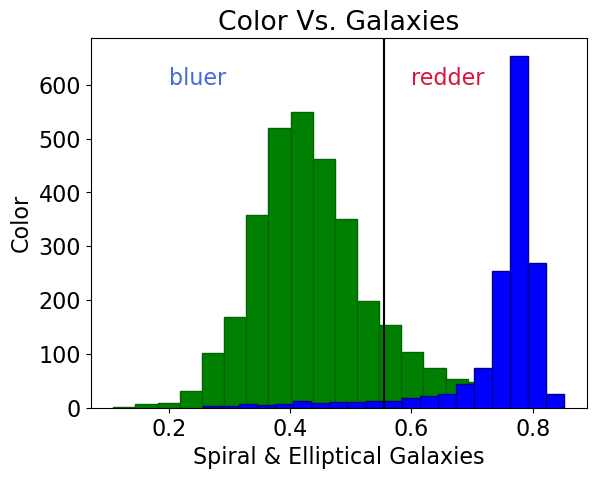

In [8]:
# create a single plot showing histograms of the colors of the two types of galaxies 
# import our graphing package and numpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

#the below is optional but makes the font a size I can read more easily
import matplotlib
matplotlib.rc('font', **{'family':'sans-serif', 'size':16}) 

# calculate color
g_band = galaxies['g band']
r_band = galaxies['r band']
color = g_band - r_band

# separate into spiral and elliptical
ell = color[elliptical] 
spi = color[spiral]

# create one histogram with elliptical and spiral galaxies on it
plt.hist(spi, bins = 20, color = 'g', edgecolor = 'darkgreen')
plt.hist(ell, bins = 20, color = 'b', edgecolor = 'darkblue')
plt.title('Color Vs. Galaxies')
plt.xlabel('Spiral & Elliptical Galaxies')
plt.ylabel('Color')

plt.axvline(np.mean(color), color ='k')
# label to the left of this line "bluer" and to the right of the line "redder" (google how to add text on your plot)
plt.annotate(xy = (0.2, 600), xytext =(0.2, 600), text = 'bluer', color = 'royalblue')
plt.annotate(xy = (0.6, 600), xytext =(0.6, 600), text = 'redder', color = 'crimson')

# statistics -- find the mean and standard deviations of the color for spirals and ellipticals
# print the stats below
print('The mean color of spiral galaxies is', round(np.mean(spi), 2))
print('The mean color of elliptical galaxies is', round(np.mean(ell), 2))
print('')
print('The standard deviation of the color of spiral galaxies is', round(np.std(spi), 2))
print('The standard deviation of the color of elliptical galaxies is', round(np.std(ell), 2))


**Are your results consistent with what you found in Galaxy Zoo?**

**Answer:** The graph is different but the mean and sd are very close

## Mergers

So far, we have confirmed that in at least some ways, the simulated galaxies behave like observed ones! Cool, but let's learn something new! I said that we can use galaxy simulations to learn about mergers. Let's do that! Read in the mergers files and check out what it contains. 

In [9]:
# read in the file mergers.csv
mergers = pd.read_csv('../Data/mergers.csv')

In [10]:
# examine the data
mergers

,Galaxy ID,Time Since Last Major Merger [Gyr],Number of Major Mergers,Numbber of Minor Mergers
0,0,5.740040,8,16
1,1,3.956615,9,5
2,2,0.799699,3,4
3,3,4.126383,7,5
4,4,6.980874,5,7
...,...,...,...,...
12530,704187,12.554805,3,2
12531,719337,9.462953,1,2
12532,727485,10.228946,7,1
12533,738596,11.317041,3,2


**How many rows are there?** 

**Answer:** 12535

**How many columns are there?**

**Answer:** 4

**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| Galaxy ID | identifer of the star | no unit 
| Time Since Last Major Merger [Gyr] |  | Gyrs 
| Number of Major Mergers | Merger where both galaxies are the same size | 
| Number of Minor Mergers | Merger where one galaxy is biger than the other  | 

# Deliverable

Explore the galaxy data you have in this notebook to make at least one plot that tells us something we haven't explored! Be ready to present. You might want to include statistics.

Text(0.5, 1.0, 'Time Since Last Major Merger Vs. Merger Galaxies')

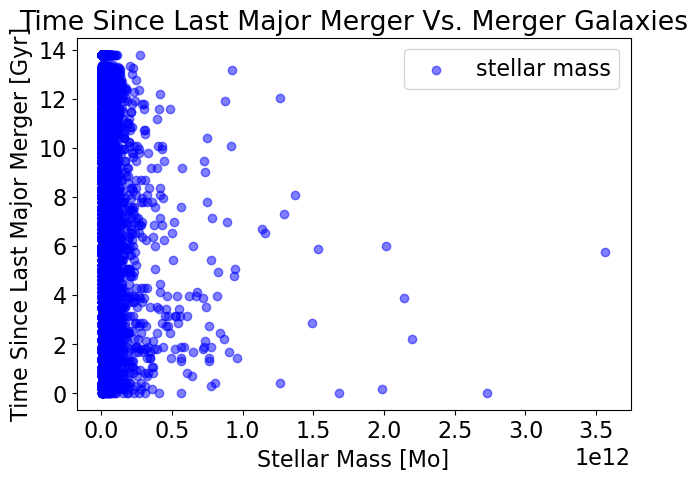

In [11]:
# explore the data and make a plot below!
TSLM = mergers['Time Since Last Major Merger [Gyr]']
major_mergers = mergers['Number of Major Mergers']
minor_mergers = mergers['Numbber of Minor Mergers']
stellar_mass = galaxies['Stellar Mass [Mo]'] 

#plt.scatter(ID, label = 'Time Since Last Major Merger [Gyr]')
#plt.plot(TSLM, color = 'k', label = 'Time since last merger')
plt.scatter(stellar_mass, TSLM, color = 'b', label = 'stellar mass', alpha = .5)
plt.legend()
plt.tight_layout()

plt.xlabel('Stellar Mass [Mo]')
plt.ylabel('Time Since Last Major Merger [Gyr]')
plt.title('Time Since Last Major Merger Vs. Merger Galaxies')

Text(0.5, 1.0, 'Number of Minor Mergers Vs. Stellar Mass')

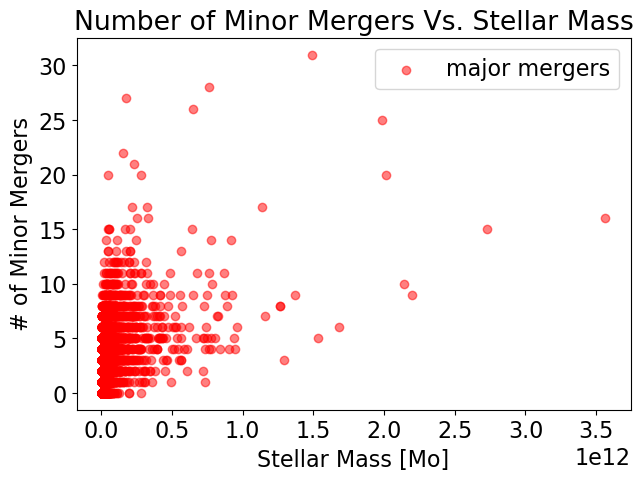

In [47]:
TSLM = mergers['Time Since Last Major Merger [Gyr]']
major_mergers = mergers['Number of Major Mergers']
minor_mergers = mergers['Numbber of Minor Mergers']
stellar_mass = galaxies['Stellar Mass [Mo]'] 
ps = galaxies['Probability is spiral']

plt.scatter(stellar_mass, minor_mergers , color = 'r', alpha = .5, label = 'major mergers')

#plt.xlim(1e11,3.5e12)
plt.legend()
plt.tight_layout()

plt.xlabel('Stellar Mass [Mo]')
plt.ylabel('# of Minor Mergers')
plt.title('Number of Minor Mergers Vs. Stellar Mass')

**According to your graph set up...**

**What is the independent variable?**

**Answer:** Stellar Mass


**What is the dependent variable?**

**Answer:** Minor Mergers


**What could a control variable be?**

**Answer:** The amount of Minor Merger Galaxies


**What shapes or trends do you see in the data?**

**Answer:** A grouping in the left hand corner


**What could this mean physically/astronomically?**

**Answer:** Most minor mergers are within the same mass range with a few outliers


**What further questions does this raise?**

**Answer:** Does the mass of the galaxy determine the size of the merger

Text(0.5, 1.0, 'Major Merger Galxies Vs. Stellar Mass')

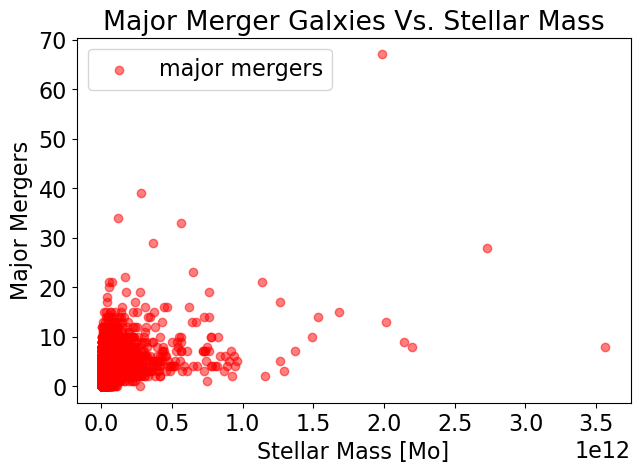

In [160]:
TSLM = mergers['Time Since Last Major Merger [Gyr]']
major_mergers = mergers['Number of Major Mergers']
minor_mergers = mergers['Numbber of Minor Mergers']
stellar_mass = galaxies['Stellar Mass [Mo]'] 
ps = galaxies['Probability is spiral']

plt.scatter(stellar_mass, major_mergers , color = 'r', alpha = .5, label = 'major mergers')

plt.legend()
plt.tight_layout()

plt.xlabel('Stellar Mass [Mo]')
plt.ylabel('Major Mergers')
plt.title('Major Merger Galxies Vs. Stellar Mass')

## Reflection

Write down some notes in your lab notebook about what you've learned in this unit about simulated galaxies. Be sure to include some astronomy and some coding. 